# PART B — Classification

## Background
The Iris dataset contains measuremnents of 150 iris flowers across three species. Your task is to build a multiclass classification model.

## Step B1: Load & Inspect the Dataset

In [1]:
# Import Packages
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
# Load the Iris dataset
iris = load_iris()

X = iris.data # Add the feature data to the DataFrame
y = iris.target # Add the target variable to the DataFrame

# Create a DataFrame from the Iris dataset
df_iris = pd.DataFrame(X, columns=iris.feature_names)

# Add the target variable to the DataFrame
df_iris['species'] = y
df_iris['species_names'] = df_iris['species'].map(dict(enumerate(iris.target_names)))

In [3]:
# Display the first few rows of the DataFrame
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_names
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [4]:
# display the last few rows of the DataFrame
df_iris.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_names
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica
149,5.9,3.0,5.1,1.8,2,virginica


In [5]:
# Shape of Dataset
df_iris.shape

(150, 6)

In [6]:
# dataset structure
df_iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_names      150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [7]:
# Statistical summary of the dataset
df_iris.describe().T

,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5
species,150.0,1.000000,0.819232,0.0,0.0,1.00,2.0,2.0


In [8]:
# NUmber of Species
df_iris[['species', 'species_names']].value_counts(ascending=False)

species  species_names
0        setosa           50
1        versicolor       50
2        virginica        50
Name: count, dtype: int64

## Step B2: Exploratory Data Analylsis (EDA)

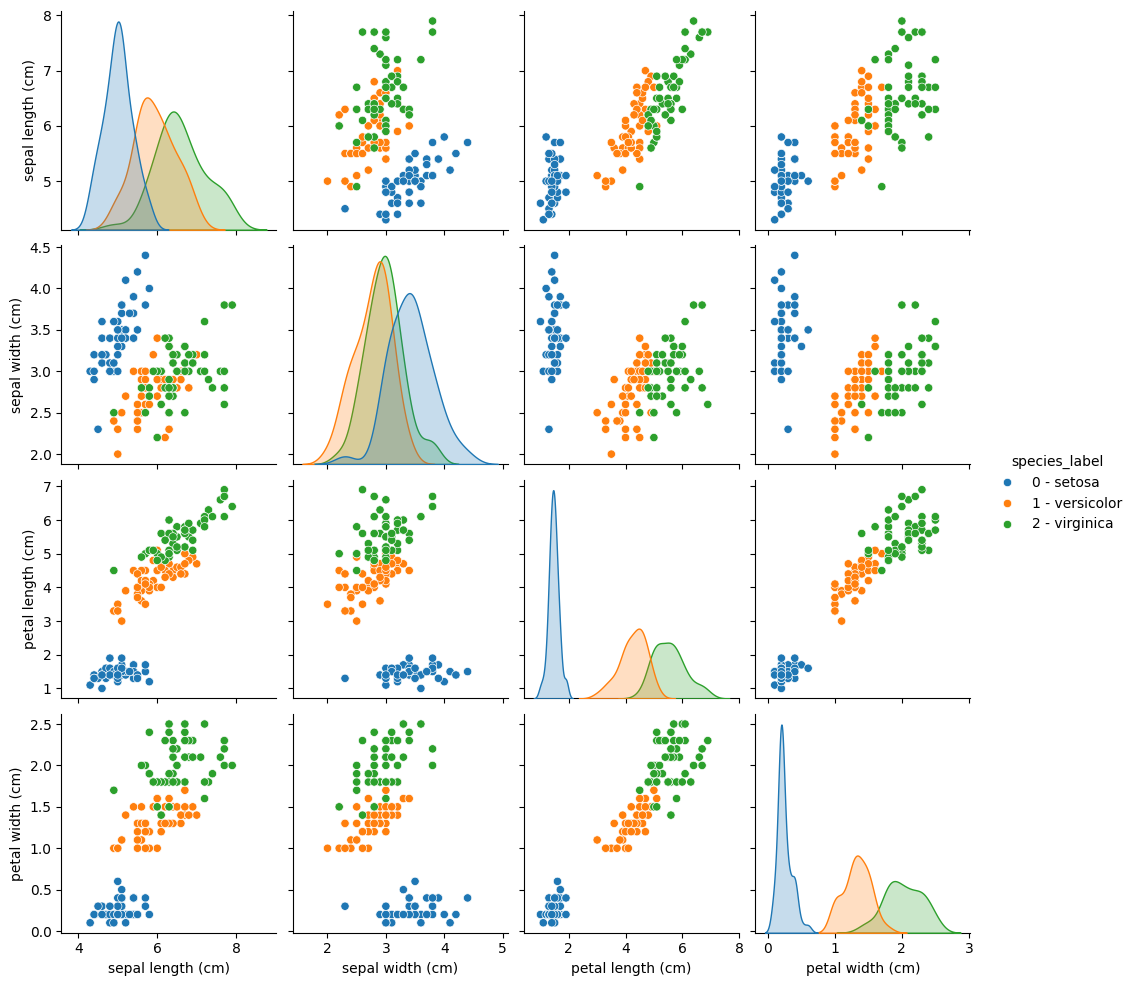

In [9]:
# Visualize the species clusters based on their features
df_iris['species_label'] = (
    df_iris['species'].astype(str) + ' - ' + 
    df_iris['species_names']
)
sns.pairplot(df_iris, vars=iris.feature_names, hue='species_label', palette='tab10')
plt.show()

### Boxplots (feature distribution)

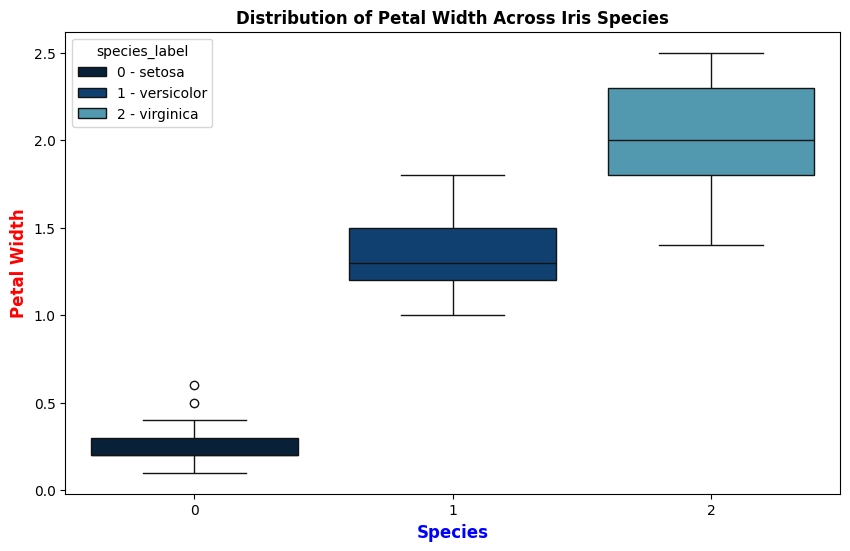

In [10]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_iris, 
    x='species', 
    y='petal width (cm)',
    hue='species_label',
    palette='ocean',
    legend=True

)
plt.title("Distribution of Petal Width Across Iris Species", fontsize=12, fontweight='bold', color='black')
plt.xlabel("Species", fontsize=12, fontweight='bold', color='blue')
plt.ylabel("Petal Width", fontsize=12, fontweight='bold', color='red')
plt.show()

## Step B3: Data Preparation

### Data Splitting

In [11]:
# Drop redundant columns
cols_to_drop = ['species_names', 'species_label'] 

df_iris_cleaned = df_iris.drop(cols_to_drop, axis=1)
df_iris_cleaned.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [12]:
# Separate the target from features
X = df_iris_cleaned.drop(columns='species')
y = df_iris_cleaned['species']

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [13]:
y.value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

In [14]:
# Split data into train and test parts.
# stratify=y keeps the 50/50/50 class balance consistent across train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Feature Scaling

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step B4: Train Classification Models

### Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression

lr_model =  LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

### Decision Tree

In [17]:
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train_scaled, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

### Random Forest

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Step B5: Evaluate Classification Models

### Predictions

In [19]:
# Define the models
models = {
    "Logistic Regression": lr_model,
    "Decision Tree Classifier": tree_model,
    "Random Forest Classifier": rf_model
}

# Compute all metrics for each model
results = []
predictions = {}

print('Evaluating models...')
for name, model in models.items():
    predictions[name] = model.predict(X_test_scaled)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, predictions[name]),
        'Precision': precision_score(y_test, predictions[name], average='macro'),
        'Recall': recall_score(y_test, predictions[name], average='macro'),
        'F1_Score': f1_score(y_test, predictions[name], average='macro')
    })
    print(f'  ✅ {name} evaluated')

print('\nAll models evaluated and predictions generated.')
print('\nGetting Classification metrics....')
df_results = pd.DataFrame(results).set_index('Model')
print('\n=== Classification Metrics — All Models (Multiclass: Iris Flower Species) ===')
df_results.round(4)

Evaluating models...
  ✅ Logistic Regression evaluated
  ✅ Decision Tree Classifier evaluated
  ✅ Random Forest Classifier evaluated

All models evaluated and predictions generated.

Getting Classification metrics....

=== Classification Metrics — All Models (Multiclass: Iris Flower Species) ===


,Accuracy,Precision,Recall,F1_Score
Model,,,,
Logistic Regression,0.9333,0.9333,0.9333,0.9333
Decision Tree Classifier,0.9333,0.9333,0.9333,0.9333
Random Forest Classifier,0.9000,0.9024,0.9000,0.8997


### Confusion Matrix for Each Model

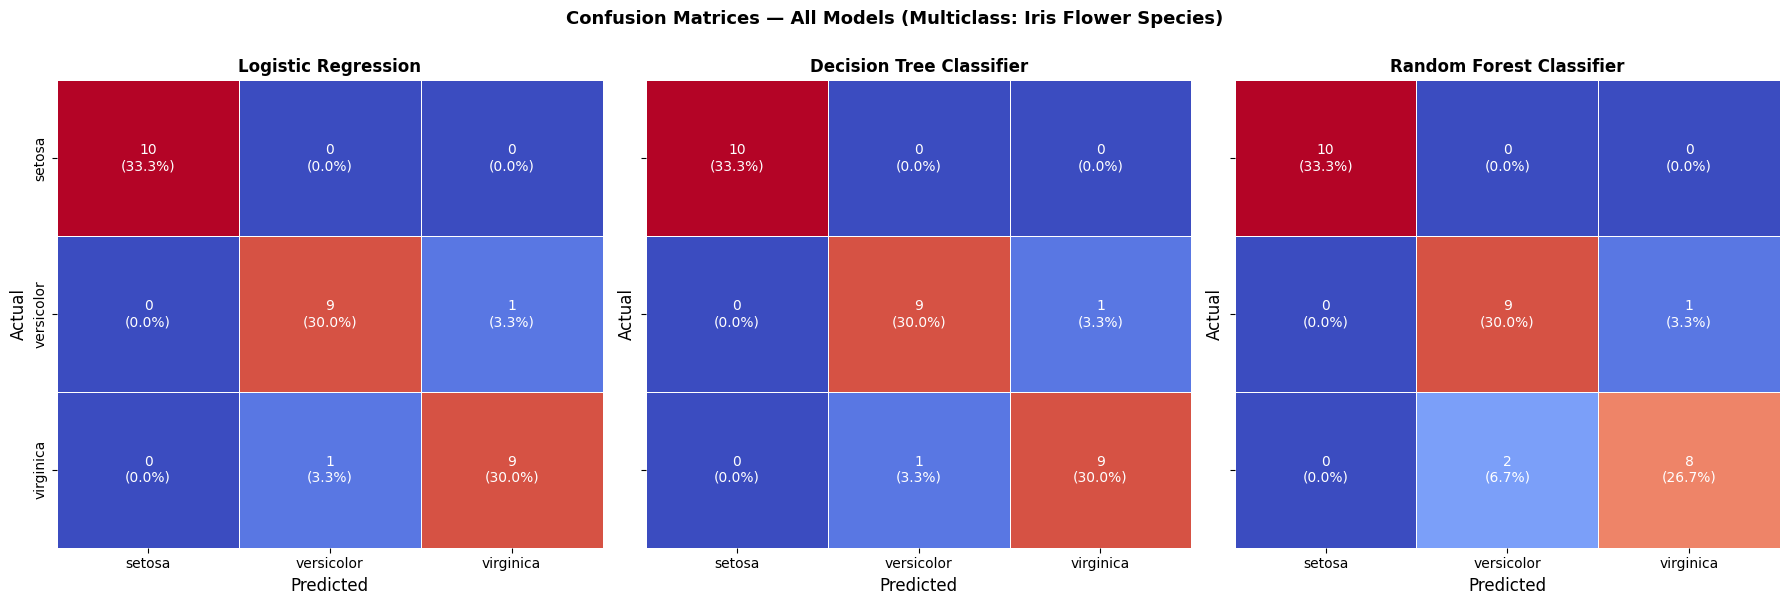

In [20]:
fig, axes = plt.subplots(
    1,3,
    figsize=(18,6),
    sharex=True,
    sharey=True,
    
)

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)

    # Annotate with both count and percentage
    total = cm.sum()
    labels = np.array([[f'{p}\n({p/total*100:.1f}%)' for p in row ] for row in cm ])

    sns.heatmap(
        cm, annot=labels, fmt='', cmap='coolwarm',
        xticklabels=iris.target_names,
        yticklabels=iris.target_names,
        ax=ax, cbar=False, linewidths=0.5)
            
    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)

plt.suptitle(
    "Confusion Matrices — All Models (Multiclass: Iris Flower Species)",
    fontsize=13, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()


## Step B6: Decision Boundary Visualisation

### Reduce to 2 features

In [21]:
# Plot how the best model separates classes in 2D feature space
# We reduce to 2 features for visualisation
# NOTE: distinct variable names (X_train_2d, etc.) used here so this split
# does NOT silently overwrite the 4-feature train/test split used in Step B4/B5

X_2d = df_iris_cleaned[['petal length (cm)', 'petal width (cm)']]
y_2d = df_iris_cleaned['species']

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_2d, test_size=0.2, random_state=42, stratify=y_2d
)

### Train model

In [22]:
# Random Forest is scale-invariant, so fitting directly on the raw petal
# measurements is fine here and keeps the plot's axes in real cm units
rf_2d = RandomForestClassifier(random_state=42)
rf_2d.fit(X_train_2d, y_train_2d)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Plot decision boundary

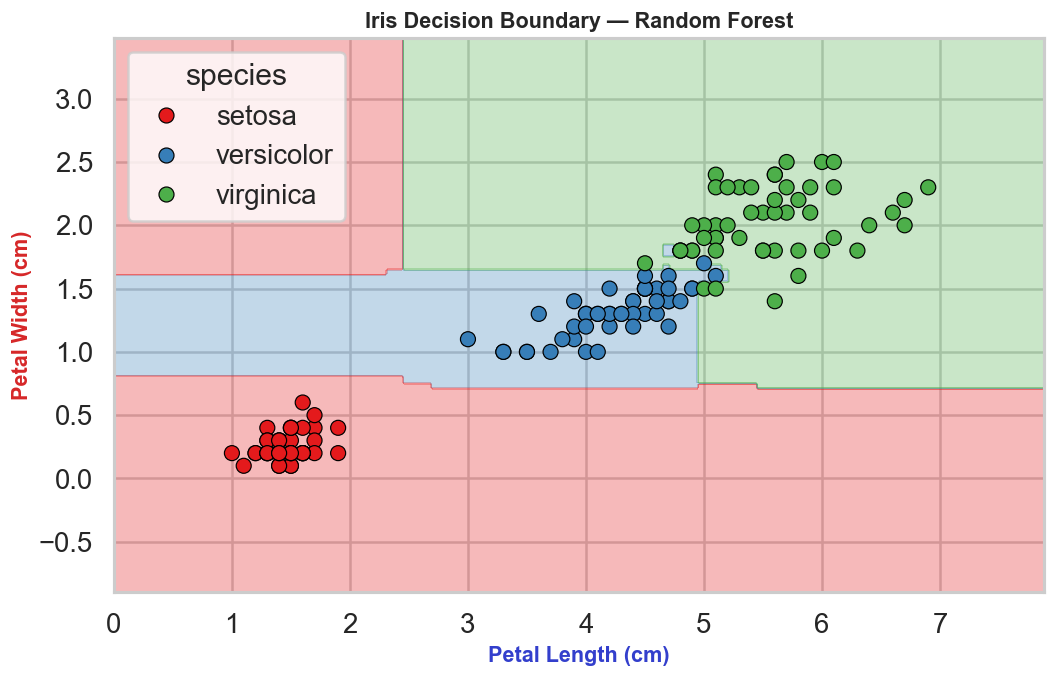

In [23]:
from matplotlib.colors import ListedColormap

# Create grid for decision boundary
x_min, x_max = X_2d.iloc[:, 0].min() - 1, X_2d.iloc[:, 0].max() + 1
y_min, y_max = X_2d.iloc[:, 1].min() - 1, X_2d.iloc[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict over grid — wrap in a DataFrame with matching column names to
# avoid sklearn's "X does not have valid feature names" warning
grid_points = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=X_2d.columns)
Z = rf_2d.predict(grid_points)
Z = Z.reshape(xx.shape)

# Use the SAME 3 colors for the decision regions as for the scatter points so the
# shading actually matches each class, instead of falling back to an unrelated colormap
class_colors = ['#e41a1c', '#377eb8', '#4daf4a']  # red, blue, green (Set1[:3])
boundary_cmap = ListedColormap(class_colors)

# Style settings scoped to just this plot, so they don't leak into earlier/later cells
with sns.axes_style("whitegrid"), sns.plotting_context("talk"):
    plt.figure(figsize=(10, 6), dpi=120)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=boundary_cmap)

    sns.scatterplot(
        x=X_2d.iloc[:, 0],
        y=X_2d.iloc[:, 1],
        hue=y_2d.map(dict(enumerate(iris.target_names))),
        hue_order=list(iris.target_names),
        palette=class_colors,
        edgecolor='black'
    )
    plt.xlabel("Petal Length (cm)", fontsize=13, fontweight="bold", color="#333fcc")
    plt.ylabel("Petal Width (cm)", fontsize=13, fontweight="bold", color="#d62728")
    plt.title("Iris Decision Boundary — Random Forest", fontsize=13, fontweight="bold")
    plt.legend(title="species")
    plt.show()


In [24]:
from matplotlib.colors import ListedColormap

def plot_decision_boundary(model, X_2d, y_2d, title, ax=None):
    x_min, x_max = X_2d.iloc[:, 0].min() - 1, X_2d.iloc[:, 0].max() + 1
    y_min, y_max = X_2d.iloc[:, 1].min() - 1, X_2d.iloc[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                          np.arange(y_min, y_max, 0.02))

    grid_points = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=X_2d.columns)
    Z = model.predict(grid_points).reshape(xx.shape)

    class_colors = ['#e41a1c', '#377eb8', '#4daf4a']  # red, blue, green
    boundary_cmap = ListedColormap(class_colors)

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(10, 6), dpi=120)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=boundary_cmap)
    sns.scatterplot(
        x=X_2d.iloc[:, 0], y=X_2d.iloc[:, 1],
        hue=y_2d.map(dict(enumerate(iris.target_names))),
        hue_order=list(iris.target_names),
        palette=class_colors, edgecolor='black', ax=ax
    )
    ax.set_xlabel("Petal Length (cm)", fontsize=12, fontweight="bold", color="#333fcc")
    ax.set_ylabel("Petal Width (cm)", fontsize=12, fontweight="bold", color="#d62728")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(title="species")

    if standalone:
        plt.tight_layout()
        plt.show()

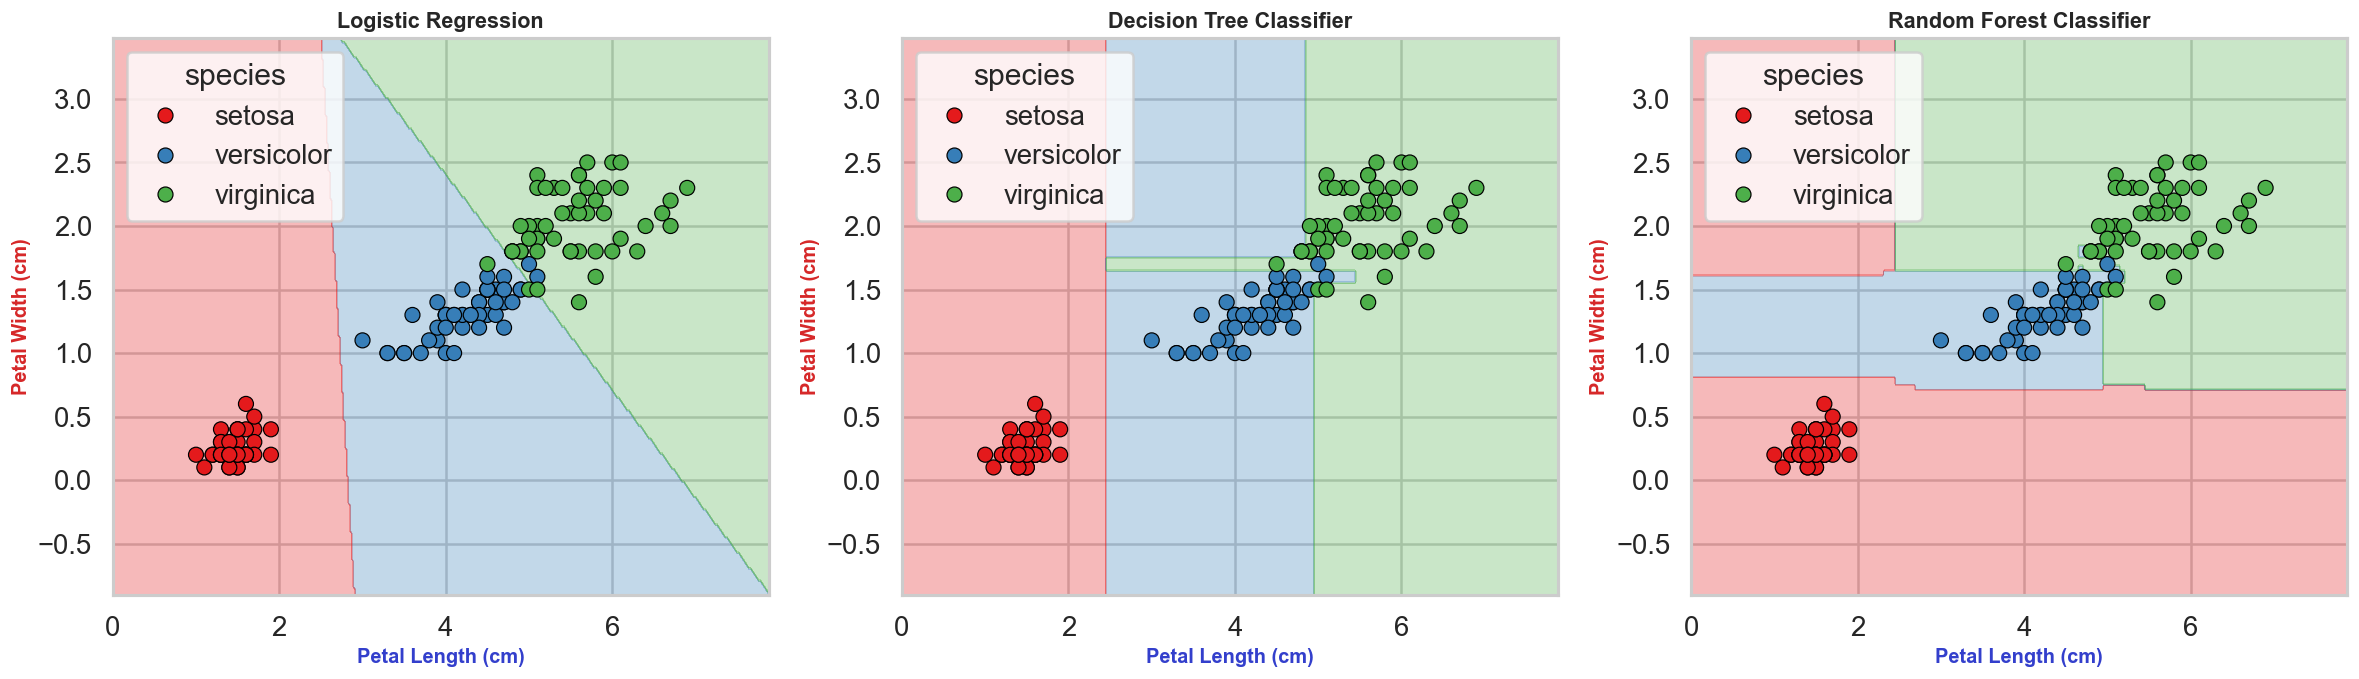

In [25]:
# Fit each model on the same 2D feature set
lr_2d   = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_2d, y_train_2d)
tree_2d = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train_2d, y_train_2d)
rf_2d   = RandomForestClassifier(random_state=42).fit(X_train_2d, y_train_2d)

models_2d = {
    "Logistic Regression": lr_2d,
    "Decision Tree Classifier": tree_2d,
    "Random Forest Classifier": rf_2d
}

with sns.axes_style("whitegrid"), sns.plotting_context("talk"):
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), dpi=120)
    for ax, (name, model) in zip(axes, models_2d.items()):
        plot_decision_boundary(model, X_2d, y_2d, name, ax=ax)
    plt.tight_layout()
    plt.show()

In [26]:
def plot_decision_boundary(model, title):
    x_min, x_max = X_2d.iloc[:, 0].min() - 1, X_2d.iloc[:, 0].max() + 1
    y_min, y_max = X_2d.iloc[:, 1].min() - 1, X_2d.iloc[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    colors = ['#e41a1c', '#377eb8', '#4daf4a']  # same colors for regions AND dots

    plt.figure(figsize=(10, 6), dpi=120)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(colors))
    sns.scatterplot(
        x=X_2d.iloc[:, 0],
        y=X_2d.iloc[:, 1],
        hue=y_2d,
        palette=colors
    )
    plt.xlabel("Petal Length (cm)", fontsize=13, fontweight="bold", color="#333fcc")
    plt.ylabel("Petal Width (cm)", fontsize=13, fontweight="bold", color="#d62728")
    plt.title(title, fontsize=13, fontweight="bold")
    plt.show()

c:\USERS\DELL\ANACONDA3\ENVS\DS-ML\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


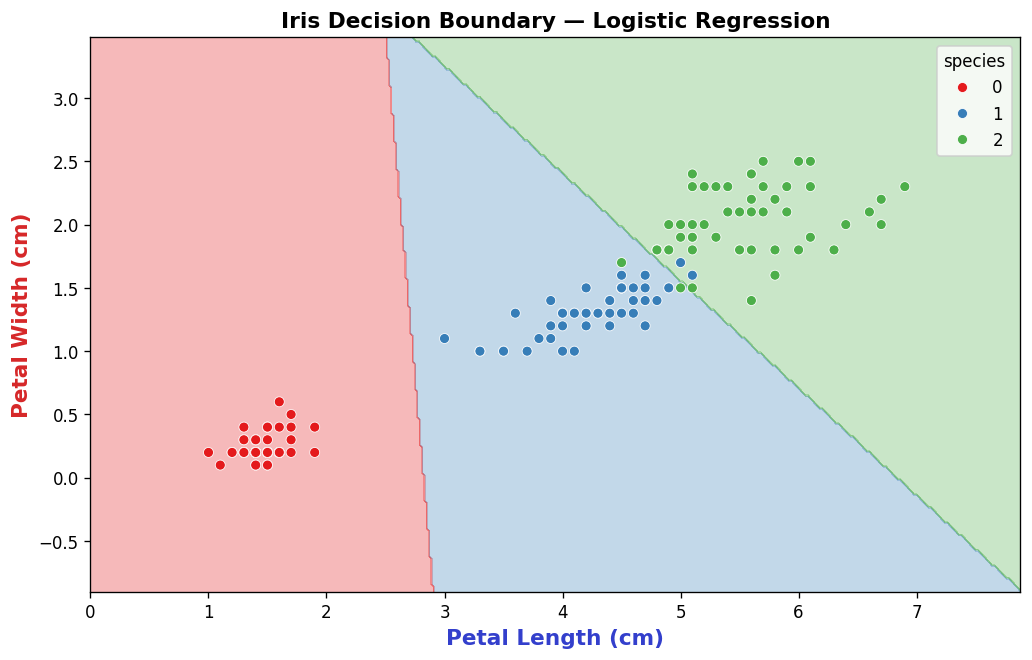

c:\USERS\DELL\ANACONDA3\ENVS\DS-ML\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


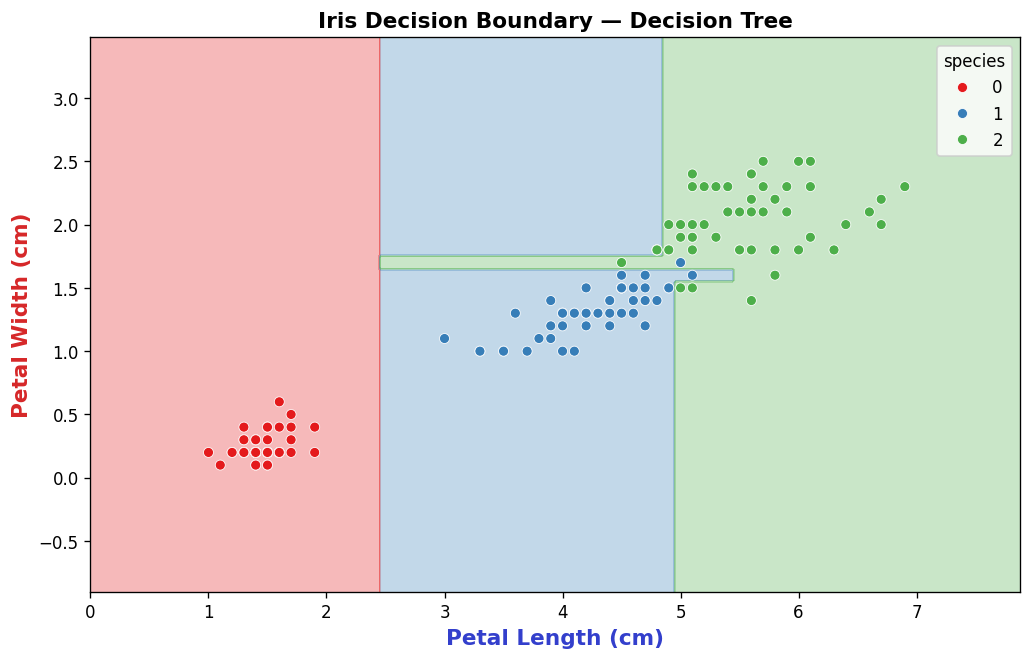

c:\USERS\DELL\ANACONDA3\ENVS\DS-ML\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


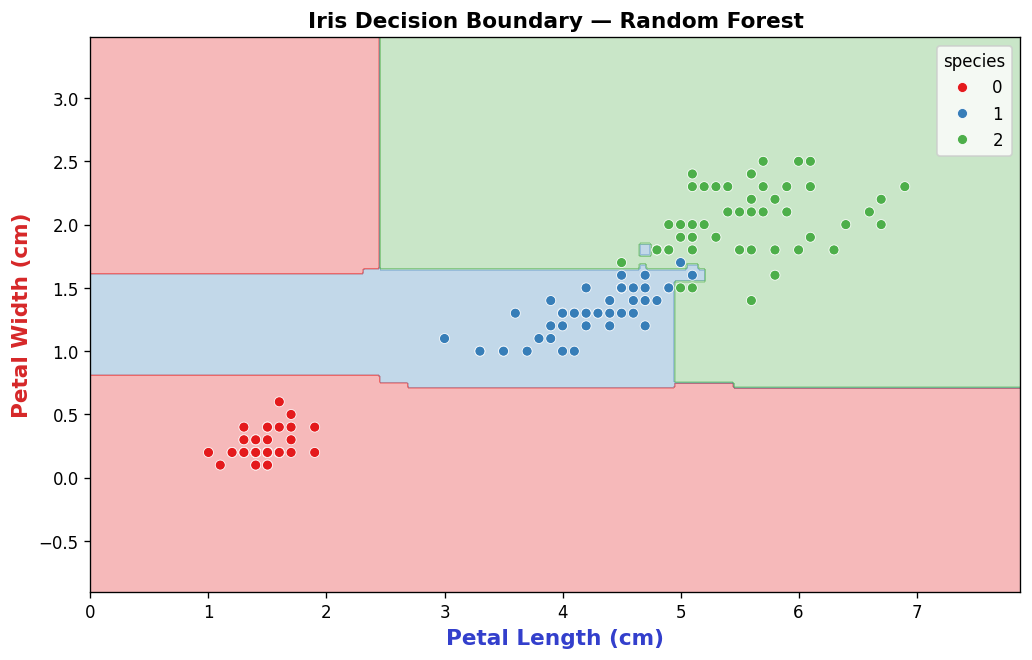

In [27]:
lr_2d   = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_2d, y_train_2d)
tree_2d = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train_2d, y_train_2d)
rf_2d   = RandomForestClassifier(random_state=42).fit(X_train_2d, y_train_2d)

plot_decision_boundary(lr_2d, "Iris Decision Boundary — Logistic Regression")
plot_decision_boundary(tree_2d, "Iris Decision Boundary — Decision Tree")
plot_decision_boundary(rf_2d, "Iris Decision Boundary — Random Forest")

In [29]:
def plot_decision_boundary(model, title, ax):
    x_min, x_max = X_2d.iloc[:, 0].min() - 1, X_2d.iloc[:, 0].max() + 1
    y_min, y_max = X_2d.iloc[:, 1].min() - 1, X_2d.iloc[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    colors = ['#e41a1c', '#377eb8', '#4daf4a']

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(colors))
    sns.scatterplot(x=X_2d.iloc[:, 0], y=X_2d.iloc[:, 1], hue=y_2d, palette=colors, ax=ax)
    ax.set_xlabel("Petal Length (cm)", fontsize=11, fontweight="bold", color="#333fcc")
    ax.set_ylabel("Petal Width (cm)", fontsize=11, fontweight="bold", color="#d62728")
    ax.set_title(title, fontsize=12, fontweight="bold")


c:\USERS\DELL\ANACONDA3\ENVS\DS-ML\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\USERS\DELL\ANACONDA3\ENVS\DS-ML\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\USERS\DELL\ANACONDA3\ENVS\DS-ML\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


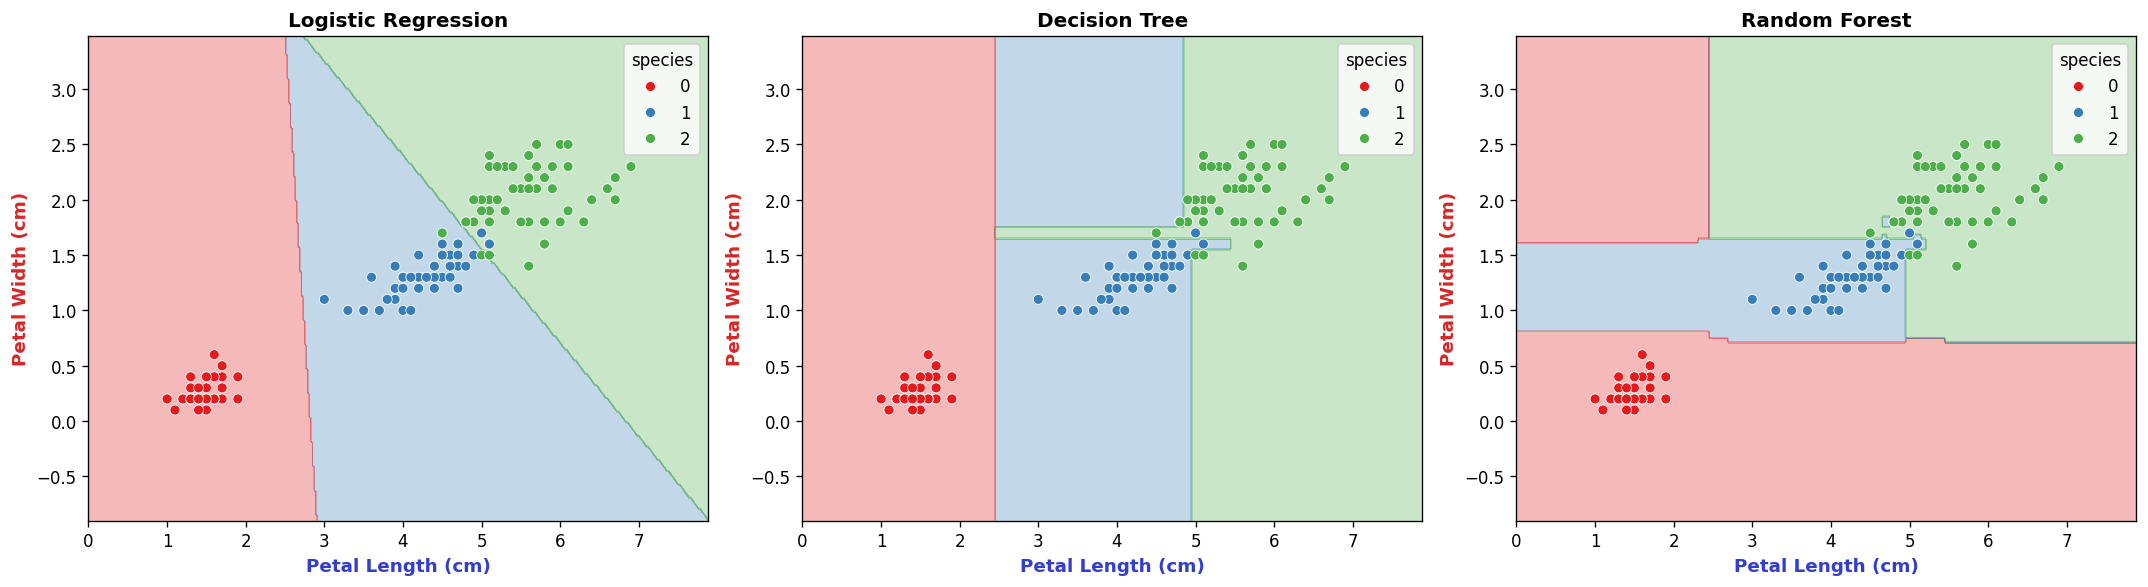

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

plot_decision_boundary(lr_2d,   "Logistic Regression", axes[0])
plot_decision_boundary(tree_2d, "Decision Tree",        axes[1])
plot_decision_boundary(rf_2d,   "Random Forest",        axes[2])

plt.tight_layout()
plt.show()

# Part C — Conceptual Quiz
---

## Section 1 — Regression (Questions 1-6)
These questions relate to Part A of the assignment — predicting California house prices.

| Questions | Q1 | Q2 | Q3 | Q4 | Q5 | Q6 |
|-----------|----|----|----|----|----|----|
| Answers   | C  | B  | B  | C  | B  | C  |

## Section 2 — Classification (Questions 7-12)
These questions relate to Part B of the assignment — predicting Iris flower species.

| Questions     |  Q7  |  Q8  |  Q9  |  Q10  |  Q11  |  Q12  |
|---------------|------|------|------|-------|-------|-------|
| **Answers**   |  B   |  B   |  C   |   B   |   C   |   C   |

## Section 3 — Classification (Questions 13-15)

##### Q13. Differences Between Regression and Classification

- Regression, is a supervised learning algorithm or predictive modelling technique used in analyzing the relationship between a dependent variable (`target`) and one or more independent variables (`features`). It involves the prediction of of a number of infinitely many possible outputs.
- **Example**: Real Estate — Prediction of house of prices (target) based on some features such as square feet, number of rooms, median income, median house value etc.
- It must be noted that we are talking about linear regression and not logistic regression which is a type of classification model.

- Classification on the other hand, which is also a supervised learning algorithm involves prediction of `classes` or `categories`. It learns from examples showing specific classes or categories of outcomes based on a particular feature, learns from the models and then tries to predict which class/category a given feature falls into.
- The classes could be either binary (0 & 1) or multi-class (more than 2 classes)

- **Example**: HealthCare — Breast cancer prediction. In the diagnosis of breast cancer, doctors try to determine if a lump or tumour is either `malignant` (cancerous/dangerous)  or `benign` (neither cancerous nor dangerous)

- The major difference between the two models is that, linear regression predicts continuous numerical values while classification predicts discrete classes or categories.

#### Q14. Interpretation for an RMSE of 0.72 where house prices are in units of $100,000 & Concrete Steps for Improvement.
- The RMSE of 0.72 means that the typical error in the regression model's prediction is about $72,000. This means that on average, the model's prediction is off by $72,000. So, for a house predicted at $300,000, the prediction would be off by $72,000 making the actual value to be typically around $228,000.

However, improvements can be made by taking the following steps:
- Reducing errors by cleaning and making sure the model learns from reliable, consistent data.
- Giving the model better context so as to increase its accuracy in understanding of business behavior.
- Trying better models like Random Forest and XGBoost to capture some non-linear relationships and complex patterns.
- Handling outliers (which affects RMSE) more carefully and fine-tunning the model so as to reduce prediction errors, and ensuring optimal performance.

#### Q15. Confusion Matrix
- From the results of my confusion matrix the two Iris species with the most consfusion were the species
